# MNIST Classification

In this assignment you will learn how to build a simple neural network that can distinguish handwritten digits between 0 and 9. Along the way you will meet the first hyperparameters that affect training — such as the learning rate and the size of the network — and you will also build a small convolutional neural network and compare it against a fully connected baseline.

Let's begin by downloading the MNIST dataset. Many common datasets are available through the `torchvision` library.

In [8]:
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import v2
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# This torchvision Dataset is just used for the Task-1 inspection;
# you'll write your own MNISTDataset next.
mnist_dataset = MNIST(root='data', download=True)

100.0%
100.0%
100.0%
100.0%


Before we go any further, let us check whether a CUDA-capable GPU is available. Training a neural network is essentially a long sequence of large matrix multiplications, and GPUs perform those orders of magnitude faster than CPUs because they execute thousands of operations in parallel. PyTorch can run the very same code on either device — we only need to tell it which one to use.

We will store the chosen device in a variable called `device` and later send our model and our tensors there with `.to(device)`.

**How to read the output of the next cell:**

* `Using device: cuda` together with a printed GPU name (e.g. `NVIDIA GeForce RTX 3090`) means PyTorch found a working GPU and training will run on it. Expect the training loop to be much faster.
* `Using device: cpu` means no compatible GPU was detected — either you are on a machine without one, or the CUDA toolkit / NVIDIA driver is not set up for PyTorch. Everything will still work; it will just take longer. This is perfectly fine for MNIST, which is small enough to train on a CPU in a few minutes.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


Next, we convert the raw MNIST `.gz` files (the original IDX binary format used by Yann LeCun's MNIST distribution) into individual PNG images on disk. Why bother?

* Later in this notebook we will build our **own** `Dataset` class (Task 2) that reads single images lazily from disk. Working with PNG files makes the lazy-loading pattern tangible and lets us inspect individual samples with any image viewer.
* It mirrors the directory layout used in many medical-imaging and computer-vision pipelines, where each class lives in its own sub-folder.

After running the cell below, the folder `./data/MNIST/raw/` will contain two new sub-directories, `training/` and `testing/`. Each of them holds one folder per digit class (`0`, `1`, ..., `9`), and every folder contains the PNG images that belong to that class. Schematically:

```
data/MNIST/raw/
├── training/
│   ├── 0/        <- all training images of digit 0 as PNGs
│   │   ├── 1.png
│   │   ├── 21.png
│   │   └── ...
│   ├── 1/
│   ├── 2/
│   ├── ...
│   └── 9/
└── testing/
    ├── 0/        <- all test images of digit 0 as PNGs
    ├── 1/
    ├── ...
    └── 9/
```

The conversion is idempotent: if the output folder already exists and is non-empty, the function returns immediately, so re-running the cell is cheap.

In [17]:
import struct


def idx_to_pngs(images_path, labels_path, out_dir):
    if os.path.isdir(out_dir) and os.listdir(out_dir):
        return
    with open(labels_path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        labels = f.read(n)
    with open(images_path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        for i in range(n):
            buf = f.read(rows * cols)
            cls = str(labels[i])
            d = os.path.join(out_dir, cls)
            os.makedirs(d, exist_ok=True)
            Image.frombytes("L", (cols, rows), buf).save(os.path.join(d, f"{i}.png"))


raw = "./data/MNIST/raw"
idx_to_pngs(f"{raw}/train-images-idx3-ubyte", f"{raw}/train-labels-idx1-ubyte", f"{raw}/training")
idx_to_pngs(f"{raw}/t10k-images-idx3-ubyte",  f"{raw}/t10k-labels-idx1-ubyte",  f"{raw}/testing")

Let's investigate the dataset. The dataset consists of tuples containing an image of a number and the number it displays. We refer to this number as the ground-truth value or label.

**Task 1 (1pts):** Investigate the dataset. First, print the size of the dataset. Then get the first element of the dataset and inspect what it contains. Plot the image and print the corresponding ground-truth label.

Length of dataset:  60000
image size:  (28, 28)


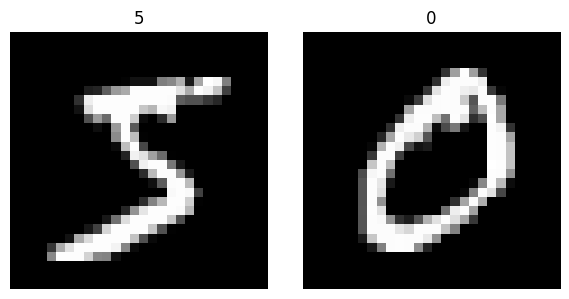

In [26]:
# TODO: print the size of the dataset, fetch the first element, inspect it,
# display the image with plt.imshow (pass cmap='gray' for the single-channel
# digit), and print its size.
# Hint: len(mnist_dataset) and mnist_dataset[0] return what you need.


def show_images(images, titles=None, cmap="gray"):
    """
    Displays a list of images side-by-side.
    
    Args:
        images: List of np.ndarray images.
        titles: Optional list of strings for titles.
        cmap: Colormap (default is 'gray' for segmentation results).
    """
    cols = 3

    n = len(images)
    m = n // cols + 1
    # Create a figure with m rows and 'min(5,n)' columns
    fig, axes = plt.subplots(m, min(cols,n), figsize=(min(n,cols) * cols, m * cols))
    
    if n > 1:
        axes = axes.flatten()
    else: 
        axes = [axes]


    for i in range(n):
        axes[i].imshow(images[i], cmap=cmap)
        
        # Add title if provided and available for this index
        if titles and i < len(titles):
            axes[i].set_title(titles[i])
            
        axes[i].axis("off") # Clean look: no pixel coordinates

    plt.tight_layout()
    plt.show()


n = len(mnist_dataset)
print("Length of dataset: ", n)

image_one, label_one = mnist_dataset[0]
image_two, label_two = mnist_dataset[1]

size_image = image_one.size

print("image size: ", size_image)

show_images([image_one,image_two],[label_one,label_two])



#raise NotImplementedError("Task 1: investigate the dataset")

As we can see, torchvision has downloaded the dataset and saved it in the folder `./data/`. In addition, it constructed a PyTorch dataset from which we can query the size or retrieve the image at a certain position, just like a numpy array. The **PyTorch Dataset** is useful to organize and iterate over our data, and it cleanly separates the data preprocessing pipeline (e.g. smoothing, removing outliers) from the actual training pipeline. It consists of three class methods: the constructor `__init__`, the `__getitem__` magic method that lets you index the dataset with the `[]`-operator, and the `__len__` method, which returns the length of the dataset. You can look up everything again here: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

**Task 2 (8pts):** Write your own Dataset class with the skeleton provided below. Inspect the data organization in `./data/MNIST/raw/training` first. The dataset should not store the entire MNIST dataset in memory at once, but should *lazily load* one image per call to `__getitem__`. The length of the dataset should equal the number of images in the training set.

**Task 3 (1pts):** We need a Dataset for training and one for testing/validating. How can we easily create a single Dataset class that works for both settings? Hint: take a look at how the data is organized on disk and how you could easily switch between the `training` and `testing` paths. You only have to alter the constructor.

To demonstrate that the same class works for both splits, also instantiate **two** dataset objects (`train_dataset` and `test_dataset`), print the length of each, and print one `(image, label)` sample from each.

In [27]:
class MNISTDataset(Dataset):
    def __init__(self, path_to_data, mode="training", transform=None):
        # TODO: store path/mode-aware book-keeping. At minimum:
        # - the resolved data directory (path_to_data + mode)
        # - the optional `transform` to apply to each loaded image
        # - decide how to enumerate every (image_path, label) pair so you can
        #   index any sample by a single integer
        raise NotImplementedError("Task 2: implement __init__")

    def __getitem__(self, idx):
        # TODO: return (image, label) for the sample with index `idx`.
        # Lazy-load the PNG with PIL.Image.open; do not preload all images.
        # If self.transform is not None, apply it to the image before returning;
        # otherwise return the raw PIL image (useful for plt.imshow inspection).
        raise NotImplementedError("Task 2: implement __getitem__")

    def __len__(self):
        # TODO: return the total number of images in the dataset.
        raise NotImplementedError("Task 2: implement __len__")


# TODO (Task 3): use the `mode` switch to instantiate the dataset for *both*
# splits. Build them without a transform so __getitem__ returns a PIL image
# you can imshow. Print the length of each dataset and one (image, label)
# sample from each. The training/testing datasets used by the dataloaders
# further down are constructed *with* a transform so they emit (1, 28, 28)
# float tensors.
#
# Expected pattern:
#   train_dataset_demo = MNISTDataset("./data/MNIST/raw", mode="training")
#   test_dataset_demo  = MNISTDataset("./data/MNIST/raw", mode="testing")
#   print(len(train_dataset_demo), len(test_dataset_demo))
#   ...
#   plt.imshow(train_img, cmap='gray')   # cmap='gray' for single-channel digits
raise NotImplementedError("Task 3: build train+test datasets and print info")

NotImplementedError: Task 3: build train+test datasets and print info

Now that you've built your own dataset, notice that we don't load every image at once but only one image per call. For large datasets — and especially in medical imaging, where images can be very large — this is more efficient: it is faster and uses much less memory.

Let's now define the neural network. There are several ways to create a neural network in PyTorch. You can define your model as a class inheriting from `torch.nn.Module`, or you can use `torch.nn.Sequential` instead.

**Question 1 (2pts):** How many input neurons does your model need to have?

*Your answer here.*

**Task 4 (5pts):** Write your own neural network using the skeleton provided. The network should include two hidden layers, and the activation function should be the **Sigmoid** function. The network should look like:

`Linear1(input_size, 128) -> sigmoid -> Linear2(128, 64) -> sigmoid -> Linear3(64, output_size)`

Note: there is no activation after the final linear layer — `CrossEntropyLoss` expects raw logits and applies log-softmax internally.

The model receives images straight from the dataloader with shape `(B, 1, 28, 28)`. To keep the training/testing loops uniform across the FC and CNN models, do the flatten **inside** `forward` (e.g. `x = x.view(x.size(0), -1)` as the first line). That way both models accept the same input shape.

In [ ]:
class MNISTModel(nn.Module):
    def __init__(self, input_size, number_of_classes):
        super().__init__()
        # TODO: define three Linear layers (input_size -> 128 -> 64 -> number_of_classes)
        # and a Sigmoid activation.
        raise NotImplementedError("Task 4: define the layers")

    def forward(self, x):
        # TODO: flatten the input from (B, 1, 28, 28) to (B, 784) using x.view(x.size(0), -1),
        # then apply Linear -> Sigmoid -> Linear -> Sigmoid -> Linear (no activation
        # on the final layer — CrossEntropyLoss wants raw logits).
        raise NotImplementedError("Task 4: implement forward")

In [ ]:
def initialize_model(m):
    # Xavier (Glorot) for Linear layers — well-suited to symmetric activations
    # like Sigmoid/Tanh. Kaiming for Conv2d, which sits in front of a ReLU in
    # our CNN — Kaiming is designed for ReLU's one-sided non-linearity.
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Conv2d):
        nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

We have to initialize our neural network. It is not a good idea to set every weight to the same value (e.g. all zeros). The reason is **symmetry**: if every neuron in a layer starts with identical weights, every neuron computes the same activation for every input, the gradients flowing back into them are identical, and the optimizer updates them identically — the layer behaves as if it had only **one** effective neuron, regardless of its width. Random initialization breaks this symmetry so that different neurons can specialize.

Xavier (Glorot) initialization, which we use for our `Linear` layers, draws weights from a distribution scaled to keep the variance of activations and gradients roughly constant across layer depth — that prevents signals from vanishing or exploding as they propagate. (As a secondary concern, with a ReLU activation all-zero weights also kill the gradient because $\mathrm{relu}(0) = 0$ and its gradient at non-positive inputs is 0; symmetry-breaking is the more general issue and applies to any activation, including the Sigmoid we use here.)

Now we configure the hyperparameters as well as the loss function, the optimizer and the model itself. Hyperparameters control the learning process of the model. Learning rate, number of epochs, and batch size are typical hyperparameters that are set before the training process starts. The PyTorch `DataLoader` is very useful for embedding our dataset into the training pipeline: it controls the batch size used in every step and shuffles the data.

In [ ]:
batch_size = 256
lr = 0.0001
epochs = 5

# Transform pipeline applied inside the Dataset:
#   v2.ToImage()                    -> tensor with channel dim, shape (1, 28, 28)
#   v2.ToDtype(float32, scale=True) -> cast to float32 and rescale 0..255 -> [0, 1]
#   v2.Normalize(mean=0.5, std=0.5) -> shift/scale into roughly [-1, 1]
# Each call to dataset[i] returns a (1, 28, 28) float32 tensor; the dataloader
# stacks a batch of them into (B, 1, 28, 28). Both the FC and the CNN model
# consume this shape — the FC one flattens internally inside forward.
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.5,), std=(0.5,)),
])

# Build the training and (re-used) test datasets *with* the transform.
train_dataset = MNISTDataset("./data/MNIST/raw", mode="training", transform=transform)
test_dataset = MNISTDataset("./data/MNIST/raw", mode="testing", transform=transform)

train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=256)

# Derive the FC input dimension from a real sample so the literal answer to
# Question 1 is not pre-printed in this cell. numel() on the (1, 28, 28)
# tensor gives the total element count after flattening.
_sample_img, _ = train_dataset[0]
INPUT_SIZE = _sample_img.numel()
model = MNISTModel(INPUT_SIZE, 10).to(device)
model.apply(initialize_model)

criterion = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

We are using the cross-entropy loss because we have 10 different classes. With `reduction="mean"` it returns the mean of the per-sample losses within a batch.

**Question 2 (1pts):** As we can see in the code, our `DataLoader` (which always returns `batch_size` images per training step) shuffles the data. Why is shuffling the data necessary before training?

*Your answer here.*

To help the network generalize to unseen data, it is common to transform the images before feeding them in. Common transformations include normalization, horizontal/vertical flipping, resizing or color distortions. We defined `transform` above and passed it into the `MNISTDataset` constructor, so every sample emerges from the dataloader as a float tensor of shape `(1, 28, 28)` normalized to roughly `[-1, 1]`.

Below we define a single `train()` function that we will reuse throughout the notebook — for the initial training run, the learning-rate comparison, and the CNN. It iterates over epochs and over the dataloader (which already yields transformed `(B, 1, 28, 28)` float tensors), sends data to the chosen device, runs the forward pass, computes the loss, backpropagates, and updates the parameters. It returns the list of average per-epoch losses.

**Task 5 (8pts):** Implement the body of the training loop in the skeleton below. Inside each epoch, iterate over the dataloader, move tensors to `device`, run the forward pass, compute the loss, and update the parameters. Remember that PyTorch accumulates gradients between calls, so you need to zero them with `zero_grad` at the right place. Accumulate the per-batch losses so the function can return the mean loss per epoch. The dataloader already yields `(B, 1, 28, 28)` float tensors — no transform call and no reshaping in the loop.

In [ ]:
def train(epochs, model, train_dataloader, optimizer, criterion):
    losses = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for img, label in tqdm(train_dataloader):
            # TODO:
            # 1) move `img` to `device` (it is already a (B, 1, 28, 28) float tensor)
            # 2) cast `label` to long and move it to `device`
            #    (.long() because CrossEntropyLoss expects int64 labels)
            # 3) forward pass through `model`
            # 4) compute the loss with `criterion`
            # 5) zero gradients, backpropagate, and step the optimizer
            # 6) accumulate the scalar loss into `total_loss`
            raise NotImplementedError("Task 5: training step")

        avg_loss = total_loss / len(train_dataloader)
        print(f"Loss after epoch {epoch}: {avg_loss}")
        losses.append(avg_loss)
    return losses


losses = train(epochs, model, train_dataloader, optimizer, criterion)

**Task 6 (7pts):** Now that we have trained our model, let us see how it performs on an unseen test dataset. Set the model to evaluation mode so the layers behave correctly during inference. **Dropout** is turned off in `eval` mode, and **BatchNorm** switches its behaviour: instead of normalising each batch with that batch's own mean and variance (as during training), it uses the running mean and variance estimated over the whole training set. So BatchNorm is *not* disabled in `eval` mode — it just stops updating and stops using per-batch statistics, which is what we want at inference time. Iterate over the dataloader (the same `test_dataloader` we built above) and collect every prediction along with its corresponding ground truth. The predictions can be calculated using the softmax function, which converts the model output into a probability distribution over the 10 labels:

$$\mathrm{softmax}(x_i) = \frac{\exp(x_i)}{\sum_{j}\exp(x_j)}$$

with $i$ being the i-th class. The class for which the model is most certain is the prediction of the model.

**Task 7 (2pts):** At the end of `test()`, calculate the confusion matrix and display it together with the accuracy of the model.

In [ ]:
def test(model, test_dataloader):
    softmax = nn.Softmax(dim=1)
    model.eval()

    test_dataset = test_dataloader.dataset
    test_batch_size = test_dataloader.batch_size

    correct = 0
    gt = np.zeros(len(test_dataset))
    preds = np.zeros(len(test_dataset))

    with torch.no_grad():
        for i, (img, label) in enumerate(tqdm(test_dataloader)):
            # TODO (Task 6):
            # 1) move `img` to `device` (already a (B, 1, 28, 28) float tensor)
            # 2) cast `label` to long and move it to `device`
            #    (.long() because CrossEntropyLoss expects int64 labels)
            # 3) forward pass through `model`
            # 4) apply softmax and take the argmax to get the predicted class
            # 5) write predictions and ground truth into `preds` / `gt`
            #    at positions [i*test_batch_size : i*test_batch_size + len(label)]
            #    Hint: convert CUDA tensors with .cpu() before .numpy()
            # 6) accumulate the number of correctly classified samples in `correct`
            raise NotImplementedError("Task 6: evaluation step")

    accuracy = correct / len(test_dataset)
    print("Accuracy:", accuracy)

    # TODO (Task 7): compute the confusion matrix from `gt` and `preds`,
    # then display it with ConfusionMatrixDisplay and plt.show().
    # YOUR CODE HERE
    return accuracy


accuracy = test(model, test_dataloader)

**Task 8 (5pts):** Let us investigate the learning process when different learning rates are used. Train a fresh model from scratch for each learning rate and store the per-epoch losses returned by `train()`. Then plot the losses against the epochs for every learning rate on the same axes. What do you observe? Which learning rate trains stably, and which one struggles or diverges?

In [ ]:
# Two learning rates that produce visibly different convergence behaviour:
#  * 0.0001 is a sensible choice for Adam on MNIST and trains smoothly.
#  * 0.5    is far too large for Adam: gradient updates overshoot the minimum,
#           the loss oscillates / diverges and accuracy stays poor.
learning_rates = [0.0001, 0.5]
losses_by_lr = {}
for current_lr in learning_rates:
    # TODO (Task 8): for each learning rate
    # 1) build a fresh MNISTModel(INPUT_SIZE, 10), move it to `device`, apply `initialize_model`
    # 2) build an Adam optimizer with this learning rate (use `current_lr`, not `lr`)
    # 3) call `train(...)` and store the returned losses in `losses_by_lr[current_lr]`
    raise NotImplementedError("Task 8: train one model per learning rate")

epoch_axis = np.arange(epochs)
for current_lr in learning_rates:
    plt.plot(epoch_axis, losses_by_lr[current_lr], label=f'Learning rate = {current_lr}')
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.ylim(0, 5)
plt.legend()
plt.show()

## A first look at convolutional neural networks

Up to this point we flattened each $28 \times 28$ image into a 784-dimensional vector before feeding it to a fully connected (FC) network. That throws away an obvious property of images: **nearby pixels carry related information**. A digit looks like a digit because of the local arrangement of strokes, not because pixel 137 happens to be bright. Convolutional neural networks (CNNs) keep the 2D spatial layout intact and learn small filters that scan the image — so they can pick up edges, corners and other local patterns wherever they occur.

A CNN is built around two operations. The first is the convolution itself, exposed in PyTorch as `nn.Conv2d(in_channels, out_channels, kernel_size, padding=..., stride=...)`. `in_channels` is how many feature maps come in (1 for a grayscale image, 16 after the first conv layer in our network, etc.), `out_channels` is how many filters we apply, and `kernel_size` is the spatial size of each filter (e.g. 3 for a $3 \times 3$ filter). `padding` adds zeros around the input so the spatial size doesn't shrink at the borders, and `stride` controls how far the filter moves between applications. Crucially, the **same** filter weights slide across the whole image — this is *weight sharing*, and it is what makes CNNs both translation-equivariant and dramatically more parameter-efficient than FC networks: a $3 \times 3$ filter has 9 weights regardless of image size, whereas a Linear layer has one weight per (input, output) pair.

The second operation is **max-pooling** (`nn.MaxPool2d(2)`). It takes the maximum value within each non-overlapping $2 \times 2$ window, halving the height and width. Pooling  downsamples the feature maps so deeper layers see a coarser, more abstract picture.

A typical small CNN for MNIST therefore looks like: convolution → ReLU → pool → convolution → ReLU → pool → flatten → a couple of fully connected layers → 10-way output. The convolutions extract increasingly abstract spatial features; the FC head turns the resulting feature vector into class scores.

**Task 9 (5pts):** Implement a small CNN with the architecture below and train it for the same number of epochs as the FC baseline using the existing `train()` function. Then evaluate it with `test()` and compare with the FC model.

Architecture:

1. `Conv2d(1 -> 16, kernel_size=3, padding=1)` -> ReLU -> `MaxPool2d(2)`
2. `Conv2d(16 -> 32, kernel_size=3, padding=1)` -> ReLU -> `MaxPool2d(2)`
3. Flatten to `(B, 32 * 7 * 7)`
4. `Linear(32 * 7 * 7 -> 64)` -> ReLU
5. `Linear(64 -> 10)` (no activation — `CrossEntropyLoss` consumes raw logits)

The CNN consumes inputs of shape `(B, 1, 28, 28)` directly — no flattening on the way in. After the two pooling layers the spatial size is `28 -> 14 -> 7`, hence the `32 * 7 * 7` input dimension of the first `Linear` layer.

In [ ]:
class MNISTConvNet(nn.Module):
    def __init__(self, number_of_classes=10):
        super().__init__()
        # TODO (Task 9): define
        # - self.conv1: Conv2d(1 -> 16, kernel_size=3, padding=1)
        # - self.conv2: Conv2d(16 -> 32, kernel_size=3, padding=1)
        # - self.pool : MaxPool2d(2)
        # - self.act  : ReLU
        # - self.fc1  : Linear(32 * 7 * 7 -> 64)
        # - self.fc2  : Linear(64 -> number_of_classes)
        raise NotImplementedError("Task 9: define the CNN layers")

    def forward(self, x):
        # TODO (Task 9): conv1 -> ReLU -> pool -> conv2 -> ReLU -> pool ->
        #                flatten with x.view(x.size(0), -1) ->
        #                fc1 -> ReLU -> fc2  (no activation on fc2)
        raise NotImplementedError("Task 9: implement forward")


cnn_model = MNISTConvNet().to(device)
cnn_model.apply(initialize_model)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=lr)
cnn_losses = train(epochs, cnn_model, train_dataloader, cnn_optimizer, criterion)
cnn_accuracy = test(cnn_model, test_dataloader)

Briefly compare your CNN against the FC baseline: the CNN typically reaches a higher test accuracy on MNIST than the small FC network, even with fewer parameters in the convolutional part, because it exploits the 2D spatial structure of the images via local receptive fields and weight sharing.

**Task 10 (5pts):** Why do we need a non-linear activation function such as
- **relu**
- **tanh**
- **sigmoid**

between two layers in a neural network? What happens if we do not use any of them? To see this, look at the computation inside the i-th layer and pass the activation $a_i$ on to the next layer $i+1$:

$$a_{i} = W_{i} \cdot a_{i-1} + b_{i}$$

$$
\begin{aligned}
a_{i+1} &= W_{i+1} \cdot a_i + b_{i+1} \\
        &= W_{i+1} \cdot (W_i \cdot a_{i-1} + b_{i}) + b_{i+1} \\
        &= W_{i+1} \cdot W_{i} \cdot a_{i-1} + W_{i+1} \cdot b_{i} + b_{i+1}
\end{aligned}
$$

*Your answer here:* what does the calculation above show, and what role does the non-linear activation play?